In [227]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

/tmp/ipykernel_34717/3683494810.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


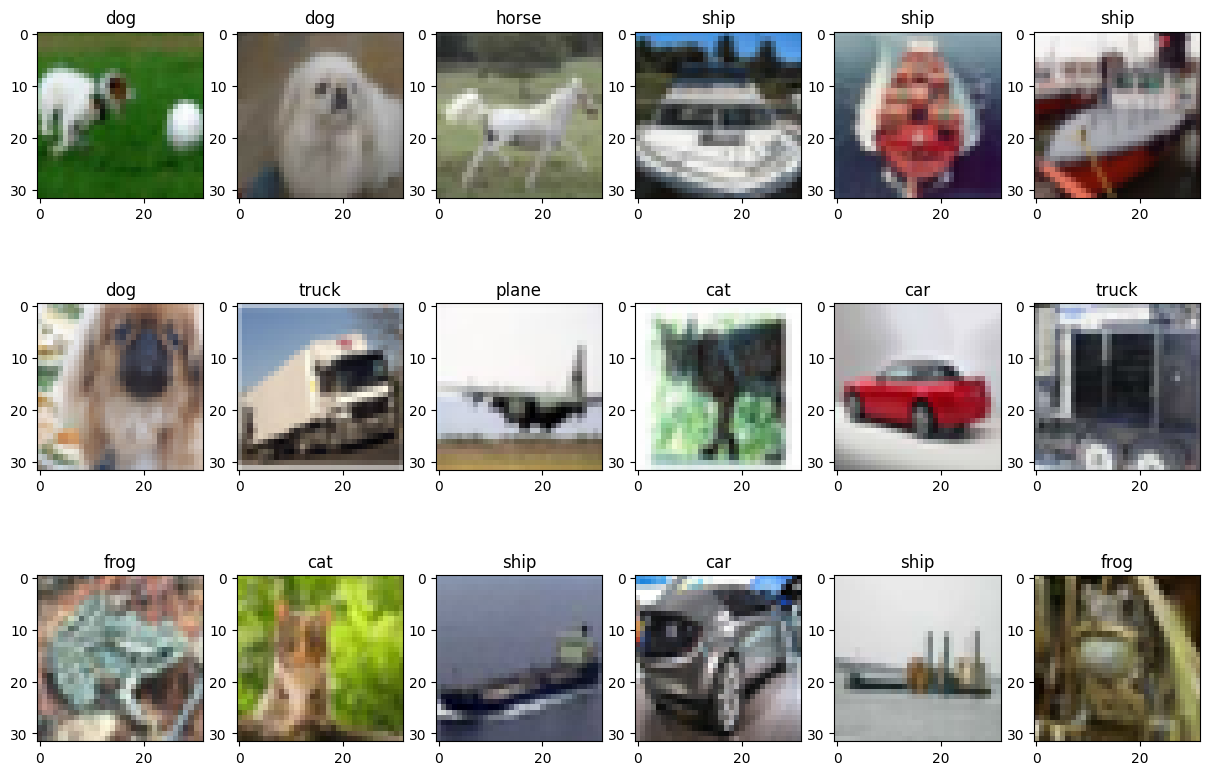

In [228]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[0]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, size)
    
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

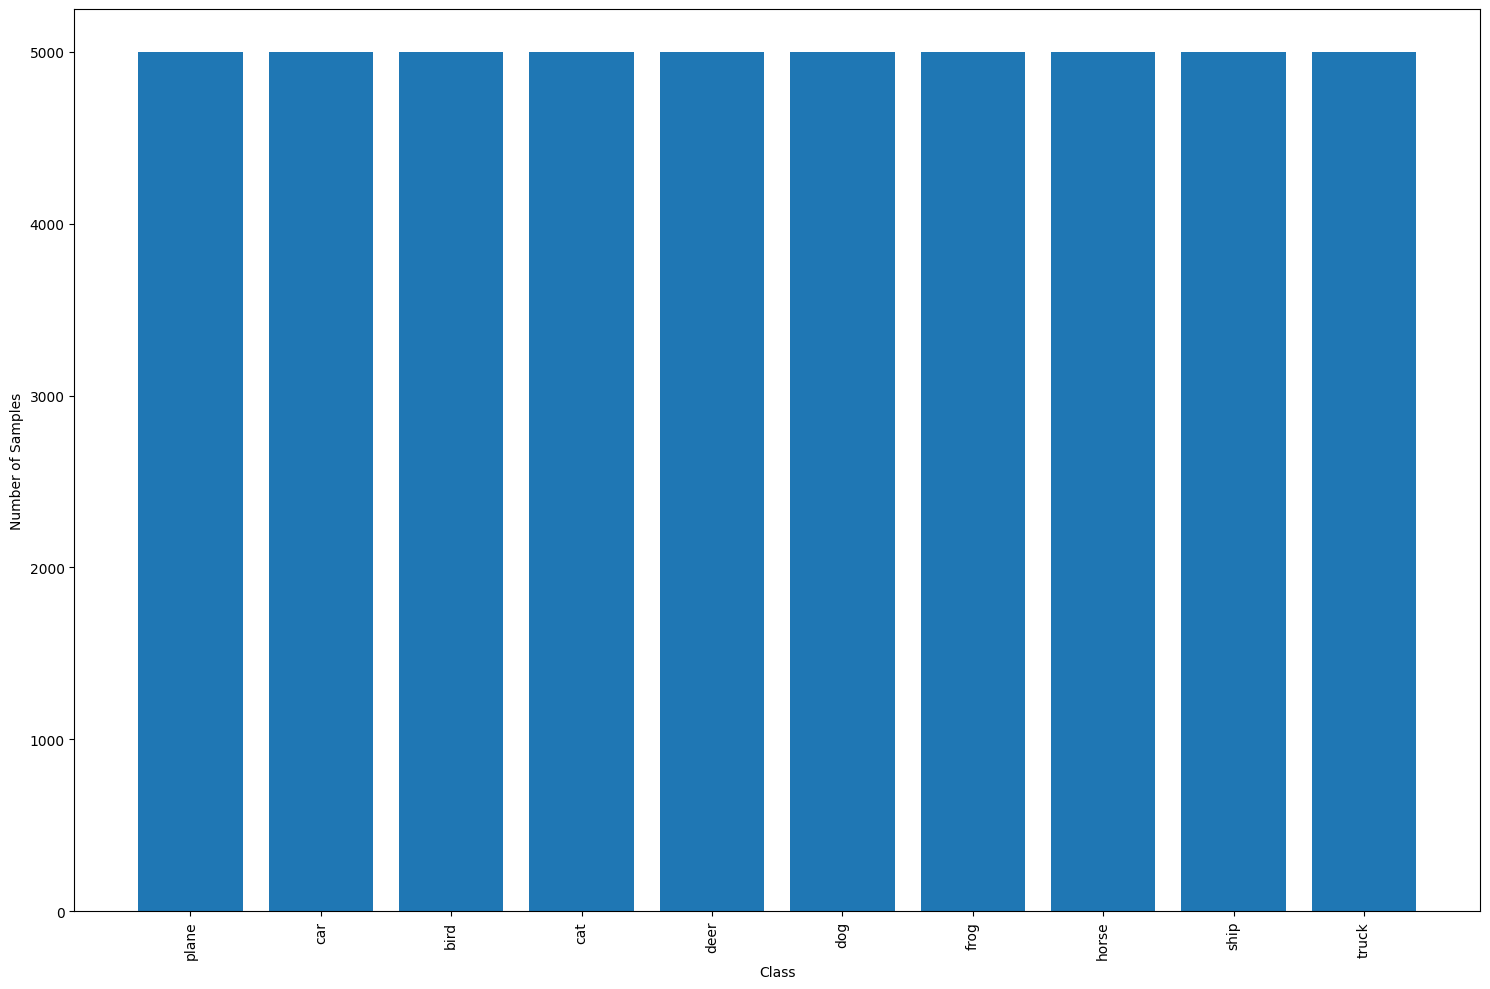

In [229]:
# Flatten y arrays
y_train = y_train.flatten()

# Count samples per class
train_counts = np.bincount(y_train)

# Training set histogram
plt.bar(classes.values(), train_counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [230]:
# Normalization
x_train = x_train/255
x_test = x_test/255

# One-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


In [231]:
size = x_train.shape[1]
print("Size : ", size)

inputs = Input(shape=(size, size, 3))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Size :  32


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,618 (64.91 KB)

 Trainable params: 16,618 (64.91 KB)

 Non-trainable params: 0 (0.00 B)

In [232]:
epochs = 35
batch_size = 128

# Compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('Elapsed time', time() - start)


Epoch 1/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3851 - loss: 1.7218 - val_accuracy: 0.4496 - val_loss: 1.5516
Epoch 2/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4957 - loss: 1.4238 - val_accuracy: 0.5084 - val_loss: 1.3996
Epoch 3/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5357 - loss: 1.3215 - val_accuracy: 0.5436 - val_loss: 1.2996
Epoch 4/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5651 - loss: 1.2481 - val_accuracy: 0.5796 - val_loss: 1.2269
Epoch 5/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5848 - loss: 1.1938 - val_accuracy: 0.5932 - val_loss: 1.1846
Epoch 6/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6008 - loss: 1.1515 - val_accuracy: 0.6032 - val_loss: 1.1577
Epoch 7/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6134 - loss: 1.1166 - val_accuracy: 0.6076 - val_loss: 1.1344
Epoch 8/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6239 - loss: 1.0869 - val_accu

Train Acc      0.7261777520179749
Validation Acc 0.6777999997138977


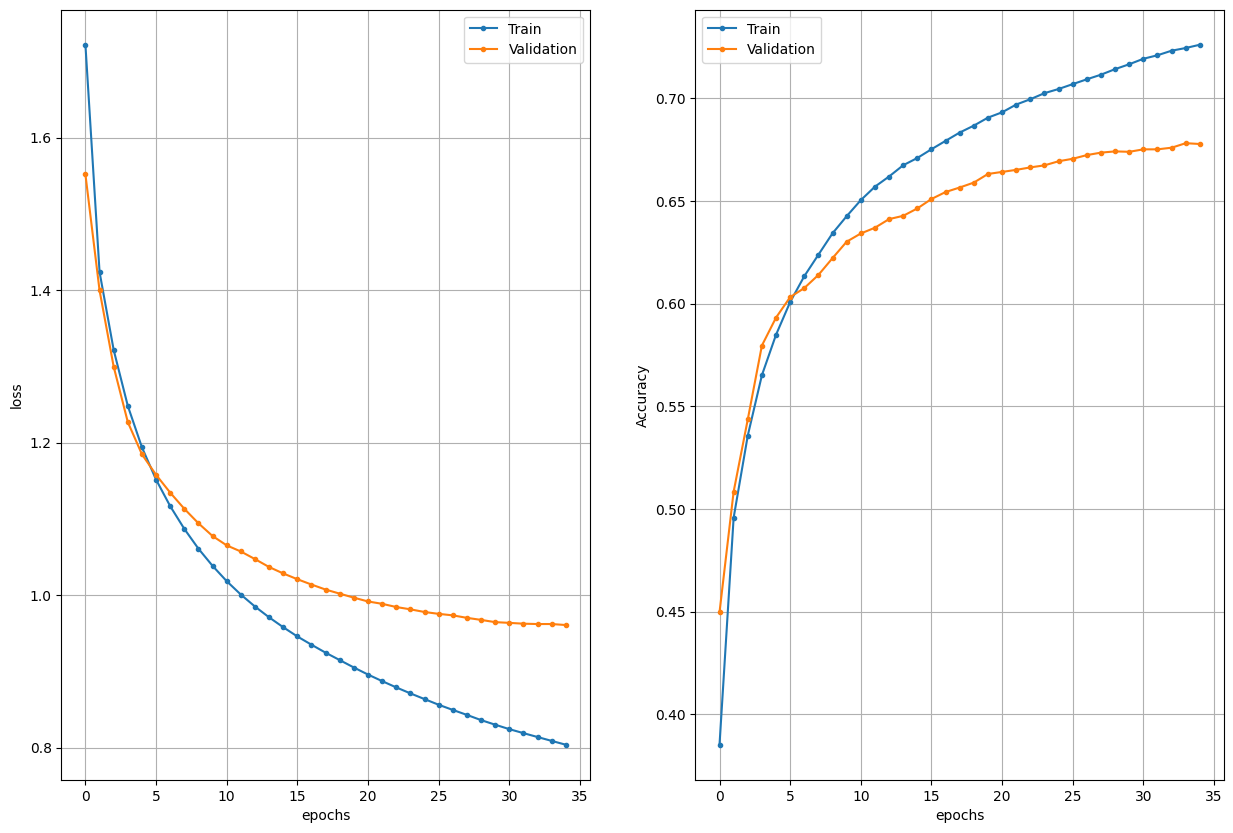

In [234]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [235]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)

print('y_pred shape = ', y_pred.shape)
print('y_true shape = ', y_true.shape)

print('True', y_true[0:5])
print('Pred', np.argmax(y_pred[0:5, :], axis=1))
print('Pred', np.argmax(y_pred, axis=1)[0:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
y_pred shape =  (10000, 10)
y_true shape =  (10000,)
True [3 8 8 0 6]
Pred [3 1 8 0 4]
Pred [3 1 8 0 4]


In [236]:
y_pred_classes = np.argmax(y_pred, axis=1)
# Compute and print the accuracy for each class
accuracy_array = np.empty(10)
for class_id, class_name in classes.items():
    mask = y_true == class_id
    tp = np.sum(y_pred_classes[mask] == class_id)
    total = np.sum(mask)
    accuracy_array[class_id] = tp/total
    print('class_id - ', class_id, ' acc', tp/total)

print('y_true', y_true[0:30])
print('y_pred', np.argmax(y_pred, axis=1)[0:30])


    

class_id -  0  acc 0.71
class_id -  1  acc 0.85
class_id -  2  acc 0.522
class_id -  3  acc 0.396
class_id -  4  acc 0.687
class_id -  5  acc 0.599
class_id -  6  acc 0.803
class_id -  7  acc 0.694
class_id -  8  acc 0.681
class_id -  9  acc 0.729
y_true [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6 7 0 4 9 5 2 4 0 9 6]
y_pred [3 1 8 0 4 6 1 6 3 1 4 9 5 7 9 6 5 7 8 6 4 2 4 9 4 4 4 0 9 6]


In [237]:
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6671 - loss: 0.9792
Test loss   0.9791516661643982
Test metric 0.6671000123023987


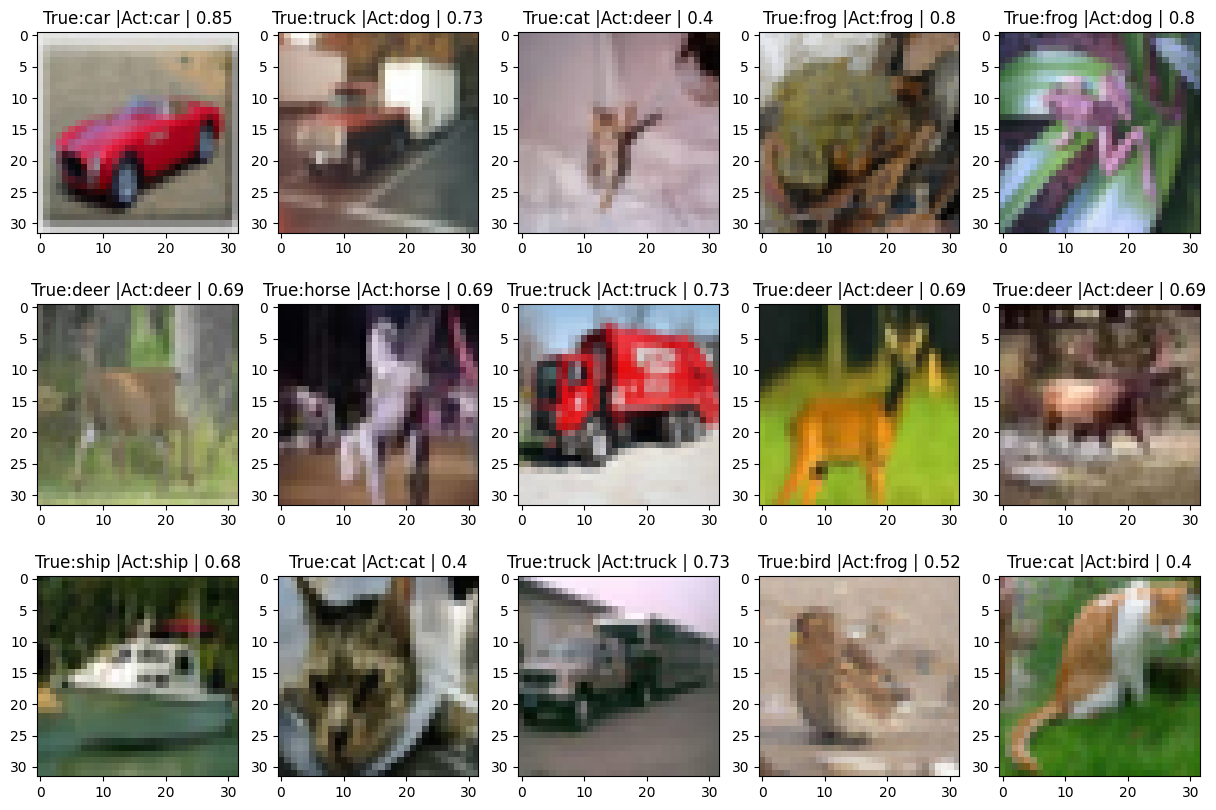

In [239]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test) - 1)
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True:' + str(classes[y_true[idx]]) + ' |Act:' + str(classes[int(y_pred_classes[idx])]) + ' | ' + str(round(accuracy_array[y_true[idx]], 2)))

In [143]:
# What is the overall accuracy of the classifier? 
#      It vary from each execution. I printed accuracy for each class above picture. In general it vary from 40% to 80% with 25 epochs
# What modifications would you do in order to improve the classification accuracy?
#      Looks like increased number of epochs to 35 improve everage accuracy 
# Make one modification (that you think can help) and train the classifier again. Does the accuracy improve?
#      1) Increased epcohs to 35 increase avarage accuracy.
#          class_id -  0  acc 0.71
#          class_id -  1  acc 0.85
#          class_id -  2  acc 0.522
#          class_id -  3  acc 0.396
#          class_id -  4  acc 0.687
#          class_id -  5  acc 0.599
#          class_id -  6  acc 0.803
#          class_id -  7  acc 0.694
#          class_id -  8  acc 0.681
#          class_id -  9  acc 0.729
#      2) Increased epcohs to 35 and increased number of neurons in first layer to 16->32
#          class_id -  0  acc 0.753
#          class_id -  1  acc 0.82
#          class_id -  2  acc 0.553
#          class_id -  3  acc 0.417
#          class_id -  4  acc 0.733
#          class_id -  5  acc 0.57
#          class_id -  6  acc 0.798
#          class_id -  7  acc 0.742
#          class_id -  8  acc 0.674
#          class_id -  9  acc 0.781